# **Загрузка данных**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, LSTM, Dropout,BatchNormalization
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.optimizers import Adam
import yfinance as yf

# Скачиваем данные Лукойла (тикер LKOH.ME для Мосбиржи)
# Период 'max' или конкретные даты, например с 2010 года
data_yf = yf.download('LKOH.ME', start='2010-01-01')

# Extract only the 'Close' price for 'LKOH.ME' and rename the column to 'CLOSE'
# The yf.download output 'data_yf' has multi-level columns like ('Close', 'LKOH.ME')
close_prices = data_yf[('Close', 'LKOH.ME')]

# Convert to a DataFrame with a single column named 'CLOSE'
data_to_save = close_prices.to_frame(name='CLOSE')

# Сохраняем только цену 'CLOSE' в 1luk.csv
data_to_save.to_csv('1luk.csv')

print("Данные скачаны и сохранены в 1luk.csv")

# 2. Генерация расширенных данных
def augment_data(data):
    features = list(data.T) # Исходные 5 каналов

    # Попарные разности, модули разностей и произведения
    n_cols = data.shape[1]
    for i in range(n_cols):
        for j in range(i + 1, n_cols):
            features.append(data[:, i] - data[:, j])           # Разность
            features.append(np.abs(data[:, i] - data[:, j]))    # Модуль разности
            features.append(data[:, i] * data[:, j])           # Произведение

    # Обратные значения x_new = 1/(x + 1e-3)
    for i in range(n_cols):
        features.append(1 / (data[:, i] + 1e-3))

    features = np.array(features).T

    # Первая производная (x[n] - x[n-1])
    diff1 = np.diff(features, axis=0, prepend=features[0:1, :])

    # Вторая производная (x[n] - 2*x[n-1] + x[n-2])
    diff2 = np.diff(diff1, axis=0, prepend=diff1[0:1, :])

    # Объединяем всё в одну матрицу
    full_data = np.hstack([features, diff1, diff2])
    return full_data

# Define base_data using the values from the data_yf DataFrame
base_data = data_yf.values

data_pro = augment_data(base_data)
print(f"Количество признаков после расширения: {data_pro.shape[1]}")

# Масштабирование
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_pro)

/tmp/ipykernel_2359/3603747641.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_yf = yf.download('LKOH.ME', start='2010-01-01')
[*********************100%***********************]  1 of 1 completed

Данные скачаны и сохранены в 1luk.csv
Количество признаков после расширения: 120


# **Создание выборки**

In [5]:
def create_pro_dataset(data, target_col_idx, look_back=100, step=1):
    X, y = [], []
    for i in range(look_back, len(data)):
        # Берем данные с определенным шагом (step), если нужно проредить историю
        X.append(data[i - look_back : i : step])
        # Предсказываем цену CLOSE (индекс 3 в исходных данных)
        y.append(data[i, target_col_idx])
    return np.array(X), np.array(y)

# Индекс колонки CLOSE в расширенном датасете остался 3 (так как оригиналы в начале)
X_pro, y_pro = create_pro_dataset(data_scaled, target_col_idx=3, look_back=100)

# Разделение на train/test
split = int(len(X_pro) * 0.8)
x_train, x_test = X_pro[:split], X_pro[split:]
y_train, y_test = y_pro[:split], y_pro[split:]

# **Построение и обучение**

In [6]:
model_pro = Sequential([
    # Сверточный слой для анализа взаимодействия признаков
    Conv1D(128, 5, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])),
    BatchNormalization(),

    # LSTM для запоминания временных зависимостей
    LSTM(64, return_sequences=False),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(1) # Прогноз цены
])

model_pro.compile(optimizer=Adam(learning_rate=1e-4), loss='mse', metrics=['mae'])

history = model_pro.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(x_test, y_test),
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.2149 - mae: 0.3838 - val_loss: 0.8169 - val_mae: 0.8293
Epoch 2/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0543 - mae: 0.1820 - val_loss: 0.5417 - val_mae: 0.6403
Epoch 3/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0404 - mae: 0.1560 - val_loss: 0.5126 - val_mae: 0.6111
Epoch 4/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0344 - mae: 0.1455 - val_loss: 0.4944 - val_mae: 0.5879
Epoch 5/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0366 - mae: 0.1479 - val_loss: 0.4178 - val_mae: 0.5251
Epoch 6/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0316 - mae: 0.1387 - val_loss: 0.3889 - val_mae: 0.4923
Epoch 7/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0293 - mae: 0.1331 - val_loss: 0.4042 - val_mae: 0.4996
Epoch 8/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0294 - mae: 0.1334 - val_loss: 0.3996 - val_mae: 0.4956
Epoch 9/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.024

# **Визуализация**

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


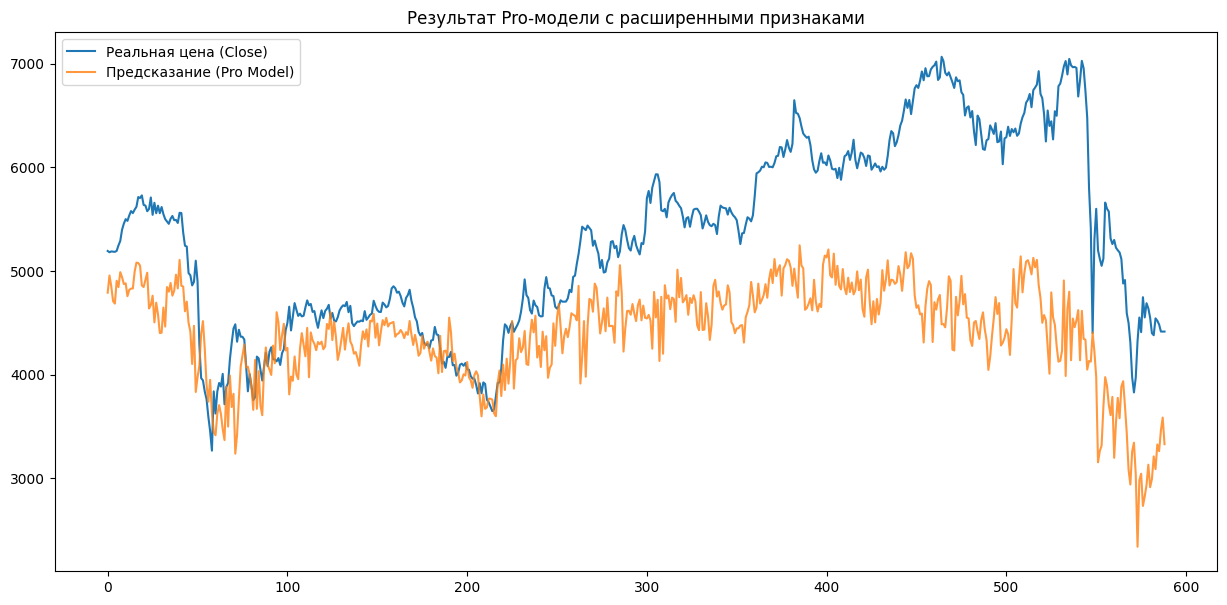

In [7]:
pred = model_pro.predict(x_test)

# Для корректного обратного масштабирования цен нужно создать временную матрицу
# (так как scaler обучался на всех признаках)
def get_original_price(scaled_val, scaler_obj, col_idx=3):
    tmp = np.zeros((len(scaled_val), scaler_obj.n_features_in_))
    tmp[:, col_idx] = scaled_val.flatten()
    return scaler_obj.inverse_transform(tmp)[:, col_idx]

y_pred_orig = get_original_price(pred, scaler)
y_true_orig = get_original_price(y_test, scaler)

plt.figure(figsize=(15, 7))
plt.plot(y_true_orig, label='Реальная цена (Close)')
plt.plot(y_pred_orig, label='Предсказание (Pro Model)', alpha=0.8)
plt.title('Результат Pro-модели с расширенными признаками')
plt.legend()
plt.show()